In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy.stats import norm

---
We want to develop a NN to learn how to use Tensorflow. We will proceed with the Black-Scholes model.

## Black-Scholes function (european call)


In [ ]:
def bs_call_price(S0, K, T, r, sigma):
    """Black-Scholes European call option price."""
    S0 = np.array(S0, dtype=float)
    d1 = (np.log(S0/K) + (r+0.5*sigma**2)*(T))/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    call_price = S0*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)
    return call_price

In [3]:
# fix some params
K=100
T=1
r=0.02
sigma = 0.25

## Input data
For this NN, we are going to generate some synthetic data.

In [13]:
n_samples = 5000

# S0 uniform between 20 and 200
S0 = np.random.uniform(20, 200, size=(n_samples, 1)).astype("float32")

# B-S call prices
C = bs_call_price(S0, K, T, r, sigma).astype("float32").reshape(-1, 1)

# train/validation split
idx = int(0.8*n_samples)
x_train, x_val = S0[:idx], S0[idx:]
y_train, y_val = C[:idx], C[idx:]


---
## Build the MLP

In [8]:
def build_mlp(input_dim=1, output_dim=1) -> keras.Model:
    # define the placeholder for the input with the given input dimension
    inputs = keras.Input(shape=(input_dim,)) 

    # first dense layer (fully connnected) with 64 neurons and activation "tanh"
    x = layers.Dense(64, activation="tanh")(inputs)
    # second dense layer, same structure
    x = layers.Dense(64, activation="tanh")(x)
    # third dense layer, same structure
    x = layers.Dense(64, activation="tanh")(x)

    # output layer (without activation function)
    outputs = layers.Dense(output_dim)(x)

    # define the model connecting inputs and outputs
    model = keras.Model(inputs=inputs, outputs=outputs)

    # compile the model with:
    #   - optimizer: Adam (adaptative gradient descent)
    #   - loss function: MSE (mean squared error)
    #   - metrics: MAE (mean absolute error)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    
    return model

In [ ]:
# build the model for the case 1D -> 1D
model = build_mlp(input_dim=1, output_dim=1)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,513 (33.25 KB)

 Trainable params: 8,513 (33.25 KB)

 Non-trainable params: 0 (0.00 B)

---
## Network training
We needs "Callbacks". We will use EarlyStopping: 
- checks the value of the loss
- if during the "patience" epochs doesnt improve, stops the training
- restore_best_weights=Ture gets the weights of the best epoch


In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        patience=20,
        monitor="val_loss",
        restore_best_weights=True
    )
]

Now comes the training:
- x_train, y_train: training data
- validation_data: used to compute val_loss and val_mae on each epoch
- epochs: max number of iterations through the dataset
- batch_size: number of samples used on each weight updating
- callbacks: list of callbacks (only EarlyStopping here)


In [16]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=500,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/500
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step - loss: 1469.9287 - mae: 28.3010 - val_loss: 1211.1434 - val_mae: 26.8841
Epoch 2/500
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - loss: 1085.4541 - mae: 23.0626 - val_loss: 830.0853 - val_mae: 17.5535
Epoch 3/500
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - loss: 762.5541 - mae: 16.4666 - val_loss: 611.8312 - val_mae: 14.0081
Epoch 4/500
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step - loss: 566.3317 - mae: 13.4808 - val_loss: 456.6222 - val_mae: 11.2804
Epoch 5/500
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step - loss: 426.1570 - mae: 11.2772 - val_loss: 346.2664 - val_mae: 9.4259
Epoch 6/500
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - loss: 321.6256 - mae: 9.2560 - val_loss: 264.0508 - val_mae: 7.8554
Epoch 7/500
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - loss: 246.0700 - mae: 8.0551 - val_loss: 201.7106 - val_mae: 6.7878
Epoch 8/500
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step - loss: 187.5311 - mae: 6.6573 - val_loss: 155.2487 - val_

---
## Evaluation and comparison


#### 1. Numerical evalutaion in the validation set
   - returns loss (MSE) and MAE, as we defined in the model compilation

In [26]:
val_loss, val_mae = model.evaluate(x_val, y_val, verbose=0)
print("Validation MSE:", val_loss)
print("Validation MAE:", val_mae)

Validation MSE: 0.013867056928575039
Validation MAE: 0.04498782753944397


In [28]:
print(C.min())

1.8165529e-10


#### 2. Generate a grid of S0 values to compare exacte and predicted curves

In [25]:
# S0 from 20 to 200 on a fine grid
S0_grid = np.linspace(20, 200, 500, dtype="float32").reshape(-1, 1)

# exact B-S prices
C_true = bs_call_price(S0_grid, K, T, r, sigma)

# predictied proces from the NN
C_pred = model.predict(S0_grid)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step


#### 3. Plot both curves on the same figure

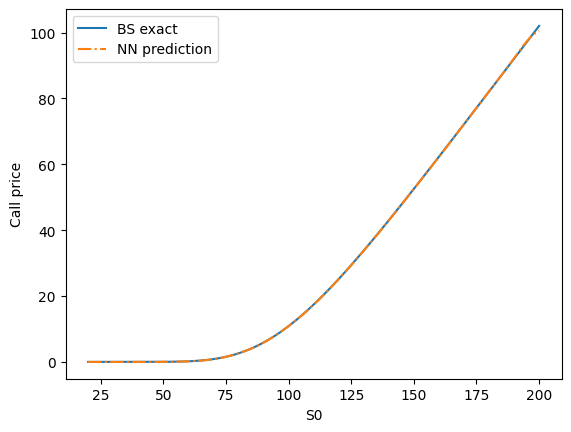

In [ ]:
plt.figure()
plt.plot(S0_grid, C_true, label="BS exact")
plt.plot(S0_grid, C_pred, '-.' , label="NN prediction")
plt.xlabel("S0")
plt.ylabel("Call price")
plt.legend()
plt.show()